In [1]:
import numpy as np
import geopandas as gpd
import rasterio as rio
from rasterio.mask import mask
from rasterio.transform import xy
from rasterio.features import shapes, geometry_mask
from shapely.geometry import Polygon, Point, shape
from skimage.segmentation import felzenszwalb
from skimage.filters import unsharp_mask
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from tqdm import tqdm
from multiprocessing.shared_memory import SharedMemory
import multiprocess as mp
import numba
from numba import prange
from typing import Tuple, Callable, Dict, Any
from src.mslandcover.config import LEGEND_CLASSES
import optuna


In [2]:
ms_places = gpd.read_file('./data/shapefiles/tl_2024_28_place')

okt_confidence_raster_path = r"Z:\guser\dh\MS_HiRes_LC_Prelim\105\lc_confidence_clipped.tif"
with rio.open(okt_confidence_raster_path) as src:
    okt_confidence_profile = src.profile

places_of_interest = ms_places.loc[ms_places['NAME'].isin(['Starkville', 'Mississippi State'])].to_crs(okt_confidence_profile['crs'])

places_of_interest = places_of_interest.dissolve()
geom = Polygon(places_of_interest['geometry'].iloc[0].exterior.coords)

with rio.open(okt_confidence_raster_path) as src:
    lc_confidence, out_transform = mask(src, [geom], crop=True, all_touched=True)
    out_profile = src.profile
    out_profile.update(
        height=lc_confidence.shape[1],
        width=lc_confidence.shape[2],
        transform=out_transform
    )
    
with rio.open(r"G:\postprocessing_tests\okt_confidence_clipped.tif", 'w', **out_profile) as dst:
    dst.write(lc_confidence)

okt_classes_raster_path = okt_confidence_raster_path.replace('confidence', 'classes')
with rio.open(okt_classes_raster_path) as src:
    lc_classes, out_transform = mask(src, [geom], crop=True, all_touched=True)
    out_profile = src.profile
    out_profile.update(
        height=lc_classes.shape[1],
        width=lc_classes.shape[2],
        transform=out_transform
    )
    cmap = src.colormap(1)

with rio.open(r"G:\postprocessing_tests\okt_classes_clipped.tif", 'w', **out_profile) as dst:
    dst.write(lc_classes)
    dst.write_colormap(1, cmap)

okt_probs_raster_path = okt_confidence_raster_path.replace('confidence', 'probs')
with rio.open(okt_probs_raster_path) as src:
    lc_probs, out_transform = mask(src, [geom], crop=True, all_touched=True)
    out_profile = src.profile
    out_profile.update(
        height=lc_probs.shape[1],
        width=lc_probs.shape[2],
        transform=out_transform
    )

with rio.open(r"G:\postprocessing_tests\okt_probs_clipped.tif", 'w', **out_profile) as dst:
    dst.write(lc_probs)

okt_imagery_raster_path = r"G:\NAIP_MS_2023\ortho_1-1_hc_s_ms105_2023_1\ortho_1-1_hc_s_ms105_2023_1_1m.tif"
with rio.open(okt_imagery_raster_path) as src:
    okt_imagery, out_transform = mask(src, [geom], crop=True, all_touched=True)
    out_profile = src.profile
    out_profile.update(
        height=okt_imagery.shape[1],
        width=okt_imagery.shape[2],
        transform=out_transform
    )

with rio.open(r"G:\postprocessing_tests\okt_imagery_clipped.tif", 'w', **out_profile) as dst:
    dst.write(okt_imagery)


lc_confidence = lc_confidence.squeeze()
lc_classes = lc_classes.squeeze()
lc_probs = lc_probs.squeeze()
okt_imagery = okt_imagery.transpose(1, 2, 0)

In [3]:
okt_probs_raster_path = '/Volumes/dhester_ssd/postprocessing_tests/okt_probs_clipped.tif'
with rio.open(okt_probs_raster_path) as src:
    lc_probs = src.read().squeeze()

okt_classes_raster_path = '/Volumes/dhester_ssd/postprocessing_tests/okt_classes_clipped.tif'
with rio.open(okt_classes_raster_path) as src:
    lc_classes = src.read().squeeze()

okt_imagery_raster_path = '/Volumes/dhester_ssd/postprocessing_tests/okt_imagery_clipped.tif'
with rio.open(okt_imagery_raster_path) as src:
    okt_imagery = src.read().transpose(1, 2, 0)
    crs = src.crs
    out_transform = src.transform
    
ms_places_gdf = gpd.read_file('./data/shapefiles/tl_2024_28_place')
places_of_interest = ms_places_gdf.loc[ms_places_gdf['NAME'].isin(['Starkville', 'Mississippi State'])].to_crs(crs)
places_of_interest = places_of_interest.dissolve()
geom = Polygon(places_of_interest['geometry'].iloc[0].exterior.coords)

sampled_points_annotated_gdf = gpd.read_file('./data/shapefiles/okt_ms_low_confidence_point_samples.gpkg')
sampled_points_annotated_gdf['one_hot'] = sampled_points_annotated_gdf['true_class_index'].apply(lambda x: np.eye(8)[x-1])


In [9]:
# randomly sample points where confidence is low
np.random.seed(1701)

n_samples = 200
max_confidence = 25

# randomly sample points where confidence is below threshold and class is not 0
pop_points = np.argwhere((lc_confidence < max_confidence) & (lc_classes != 0))
sample_indices = np.random.choice(range(pop_points.shape[0]), n_samples, replace=False)
sample_points = pop_points[sample_indices]

# get predicted classes for each sample point
sample_classes = lc_classes[sample_points[:, 0], sample_points[:, 1]]
sample_class_names = [LEGEND_CLASSES[cls] for cls in sample_classes]

# convert sample points to coordinates in raster crs
sample_coords = [Point(xy(out_transform, point[0], point[1])) for point in sample_points]

def get_probs(point: Point, lc_probs: np.ndarray, out_transform: rio.transform.Affine) -> np.ndarray:
    row, col = rowcol(out_transform, point.x, point.y)
    return lc_probs[:, row, col] / 100.0

pred_probs = [get_probs(point, lc_probs, out_transform) for point in sample_coords]

sampled_points_gdf = gpd.GeoDataFrame({
    'confidence': lc_confidence[sample_points[:, 0], sample_points[:, 1]],
    'pred_class_index': sample_classes,
    'pred_class_name': sample_class_names,
    'pred_probs': pred_probs
},geometry=sample_coords, crs=places_of_interest.crs)
sampled_points_gdf.to_file(r"G:\postprocessing_tests\sampled_points.gpkg")

In [10]:
@numba.njit(parallel=True)
def process_chunk_vectorized(
    chunk_seg: np.ndarray, 
    lc_probs_chunk: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Update probabilities in a chunk based on segment averages.

    For each unique segment in the chunk, compute the mean probability 
    across all pixels for each channel and assign the computed mean to 
    all pixels in that segment.

    Parameters
    ----------
    chunk_seg : np.ndarray
        2D array representing segmentation labels for the current image chunk.
    lc_probs_chunk : np.ndarray
        3D array with shape (channels, height, width) containing probability values 
        corresponding to the image chunk.

    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        A tuple containing:
        - The segmentation chunk with unchanged labels.
        - The updated probability chunk with each pixel replaced by its channel mean.
    """
    unique_segments = np.unique(chunk_seg)
    
    # Loop over each unique segment in parallel.
    for s in prange(unique_segments.shape[0]):
        segment = unique_segments[s]
        # Boolean mask: True for pixels belonging to the current segment.
        mask = (chunk_seg == segment)
        
        # Process each probability channel.
        for i in range(lc_probs_chunk.shape[0]):
            s_val = 0.0
            cnt = 0
            # Sum and count probability values over all pixels in the segment.
            for idx in range(mask.size):
                if mask.flat[idx]:
                    s_val += lc_probs_chunk[i].flat[idx]
                    cnt += 1
            # Compute mean probability for the segment; avoid division by zero.
            mean_val = s_val / cnt if cnt > 0 else 0.0
            # Assign the mean value back into each pixel of the segment.
            for idx in range(mask.size):
                if mask.flat[idx]:
                    lc_probs_chunk[i].flat[idx] = mean_val
    return chunk_seg, lc_probs_chunk


def process_chunk(
    image_chunk: np.ndarray,
    seg_func: Callable[..., np.ndarray],
    seg_params: Dict[str, Any],
    lc_probs_chunk: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Segment a chunk of the image and update its corresponding probability values.

    Applies a segmentation function to a chunk of the image and then uses the 
    vectorized processing to update the probability chunk based on segment means.

    Parameters
    ----------
    image_chunk : np.ndarray
        A sub-array of the overall image to be segmented.
    seg_func : Callable[..., np.ndarray]
        Segmentation function (e.g., felzenszwalb) that accepts the image chunk and parameters.
    seg_params : dict
        Dictionary of parameters to be passed to the segmentation function.
    lc_probs_chunk : np.ndarray
        A sub-array of the probability array corresponding to the image chunk.

    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        A tuple containing:
        - The segmentation mask for the chunk.
        - The updated probability chunk.
    """
    # Segment the image chunk with the provided segmentation function.
    chunk_seg = seg_func(image_chunk, **seg_params)
    # Update probability values based on segment statistics.
    chunk_seg, lc_probs_chunk = process_chunk_vectorized(chunk_seg, lc_probs_chunk)
    return chunk_seg, lc_probs_chunk


def parallel_segment(
    image: np.ndarray,
    lc_probs: np.ndarray,
    seg_func: Callable[..., np.ndarray],
    seg_params: Dict[str, Any],
    chunk_size: int = 1024,
    n_procs: int = 16,
    enable_pbar: bool = True,
) -> Tuple[np.ndarray, np.ndarray, Dict]:
    """
    Segment a full image in parallel and update probability values accordingly.

    Divides the image and its corresponding probability array into chunks, processes each 
    chunk in parallel, and then reassembles the full segmented image, updated probabilities, 
    and a mapping from segment IDs to normalized mean probabilities.

    Parameters
    ----------
    image : np.ndarray
        The full image data as a numpy array with shape (height, width, channels) or similar.
    lc_probs : np.ndarray
        The probability array with shape (channels, height, width).
    seg_func : Callable[..., np.ndarray]
        The segmentation function to apply to each image chunk.
    seg_params : dict
        Parameters for the segmentation function.
    chunk_size : int, optional
        The size of each chunk (default is 1024). The image is divided into non-overlapping 
        chunks of shape (chunk_size, chunk_size).
    n_procs : int, optional
        Number of processes to run in parallel (default is 16).

    Returns
    -------
    Tuple[np.ndarray, np.ndarray, dict]
        A tuple containing:
        - segmented_image: np.ndarray with unique segment labels for the whole image.
        - processed_probs: np.ndarray with updated probability values.
        - segment_mapping: Dictionary mapping each segment ID to its normalized mean probabilities.
    """
    img_height, img_width = image.shape[:2]
    segmented_image = np.zeros((img_height, img_width), dtype=np.int32)
    processed_probs = np.zeros(lc_probs.shape, dtype=lc_probs.dtype)
    segment_mapping: Dict = {}

    # Generate a list of chunk starting indices.
    chunks = [(i, j) for i in range(0, img_height, chunk_size) for j in range(0, img_width, chunk_size)]
    
    # Create shared memory for the lc_probs array to avoid duplicating large arrays.
    shm_probs = SharedMemory(create=True, size=lc_probs.nbytes)
    shared_probs = np.ndarray(lc_probs.shape, dtype=lc_probs.dtype, buffer=shm_probs.buf)
    shared_probs[:] = lc_probs[:]

    # Prepare arguments for processing each chunk.
    args = []
    for i, j in chunks:
        img_chunk = image[i:i+chunk_size, j:j+chunk_size]
        # Copy the corresponding chunk of probability data.
        lc_chunk = shared_probs[:, i:i+chunk_size, j:j+chunk_size].copy()
        args.append((img_chunk, seg_func, seg_params, lc_chunk, i, j))

    def process_wrapper(
        arg: Tuple[np.ndarray, Callable[..., np.ndarray], Dict[str, Any], np.ndarray, int, int]
    ) -> Tuple[int, int, np.ndarray, np.ndarray]:
        """
        Unpack arguments and process a single image-chunk.

        Parameters
        ----------
        arg : tuple
            A tuple containing:
            - image_chunk: np.ndarray
            - seg_func: segmentation function
            - seg_params: parameters for seg_func
            - lc_probs_chunk: np.ndarray for current chunk probabilities
            - i, j: starting indices in the full image

        Returns
        -------
        tuple
            A tuple containing:
            - i: row index of chunk start.
            - j: column index of chunk start.
            - chunk_seg: processed segmentation of the chunk.
            - updated_chunk_probs: updated probability chunk.
        """
        img_chunk, seg_func, seg_params, lc_chunk, i, j = arg
        chunk_seg, updated_chunk_probs = process_chunk(img_chunk, seg_func, seg_params, lc_chunk)
        return i, j, chunk_seg, updated_chunk_probs

    running_max = 0
    # Process chunks in parallel using a process pool.
    with mp.Pool(n_procs) as pool:
        for i, j, chunk_seg, updated_chunk_probs in tqdm(
            pool.imap_unordered(process_wrapper, args),
            total=len(args),
            desc="Processing chunks",
            unit="chunk",
            disable=not enable_pbar,
        ):
            # Ensure unique segment labels across chunks.
            chunk_seg += running_max
            segmented_image[i:i+chunk_size, j:j+chunk_size] = chunk_seg
            processed_probs[:, i:i+chunk_size, j:j+chunk_size] = updated_chunk_probs
            # For each segment, compute normalized mean probabilities.
            unique_ids = np.unique(chunk_seg)
            for seg in unique_ids:
                mask = (chunk_seg == seg)
                mean_probs = np.mean(updated_chunk_probs[:, mask], axis=1)
                total = np.sum(mean_probs)
                segment_mapping[seg] = mean_probs / total if total != 0 else mean_probs
            running_max = np.max(unique_ids) + 1

    # Clean up shared memory.
    shm_probs.close()
    shm_probs.unlink()

    return segmented_image, processed_probs, segment_mapping




In [5]:
def cross_entropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred))

In [10]:
bounding_mask = geometry_mask(
    [geom], 
    out_shape=lc_probs.shape[1:], 
    transform=out_transform, 
    invert=True, 
    all_touched=True
)

def objective(trial):
    # sample segmentation parameters
    scale = trial.suggest_float("scale", 10, 500)
    min_size = trial.suggest_int("min_size", 5, 100)
    sigma = trial.suggest_float("sigma", 0.0, 10.0)
    # chunk_size = trial.suggest_categorical("chunk_size", [256, 512, 1024, 2048])
    unsharp_radius = trial.suggest_int("unsharp_radius", 0, 20)
    unsharp_amount = trial.suggest_float("unsharp_amount", 0.0, 2.0)
    params_trial = {'scale': scale, 'min_size': min_size, 'sigma': sigma}
    
    try:
        
        if unsharp_radius < 0.01 or unsharp_amount == 0.0:
            okt_imagery_sharpened = okt_imagery
        else:
            okt_imagery_sharpened = unsharp_mask(okt_imagery, radius=unsharp_radius, amount=unsharp_amount)
        
        # run segmentation
        segmented_image, _, segment_mapping = parallel_segment(
            okt_imagery_sharpened, lc_probs, felzenszwalb, params_trial, chunk_size=256, n_procs=mp.cpu_count()
        )
        
        
        segment_id_geoms = [
            (shape(geom), seg_id) 
            for geom, seg_id in shapes(segmented_image, mask=bounding_mask, connectivity=4, transform=out_transform)
        ]
        
        segmented_gdf = gpd.GeoDataFrame({
            'segment_id': [seg_id for _, seg_id in segment_id_geoms],
            'mean_probs': [segment_mapping[seg_id] for _, seg_id in segment_id_geoms],
        }, geometry=[geom for geom, _ in segment_id_geoms], crs=places_of_interest.crs)
        segmented_gdf['new_pred_class_index'] = segmented_gdf['mean_probs'].apply(lambda x: np.argmax(x) + 1)
        
        # spatial join with annotated sample points and compute loss
        results_gdf = gpd.sjoin(sampled_points_annotated_gdf, segmented_gdf, how='left')
        y_true = np.stack(results_gdf['one_hot'].values)
        y_pred = np.stack(results_gdf['mean_probs'].values)
        loss_value = cross_entropy(y_true, y_pred)
        
        # compute accuracy and weighted f1 score
        true_labels = np.argmax(y_true, axis=1)
        pred_labels = np.argmax(y_pred, axis=1)
        
        acc = accuracy_score(true_labels, pred_labels)
        trial.set_user_attr('accuracy', acc)
        
        for average_type in ['micro', 'macro', 'weighted']:
            precision = precision_score(true_labels, pred_labels, average=average_type, zero_division=0)
            recall = recall_score(true_labels, pred_labels, average=average_type, zero_division=0)
            f1 = f1_score(true_labels, pred_labels, average=average_type, zero_division=0)
            
            trial.set_user_attr(f'{average_type}_precision', precision)
            trial.set_user_attr(f'{average_type}_recall', recall)
            trial.set_user_attr(f'{average_type}_f1_score', f1)
        
    except Exception as e:
        loss_value = np.inf  # if any error occurs, use infinity to indicate a failed trial
        print(f'====================')
        print(f'{type(e).__name__}: {e}')
        print(f'Trial params: {params_trial}')
        print(f'====================')
        
        trial.set_user_attr('error', e)
        
    return loss_value

study = optuna.create_study(study_name='seg_alg_test', direction='minimize')
study.optimize(objective, n_trials=1)

print("Best trial:")
print("Params: ", study.best_trial.params)
print("Loss: ", study.best_trial.value)
print("Macro F1 Score: ", study.best_trial.user_attrs.get('macro_f1_score'))
print("Accuracy: ", study.best_trial.user_attrs.get('accuracy'))

original_f1 = f1_score(sampled_points_annotated_gdf['true_class_index'], sampled_points_annotated_gdf['pred_class_index'], average='macro')
original_acc = accuracy_score(sampled_points_annotated_gdf['true_class_index'], sampled_points_annotated_gdf['pred_class_index'])

f1_improvement = (study.best_trial.user_attrs.get('macro_f1_score') - original_f1) / original_f1
acc_improvement = (study.best_trial.user_attrs.get('accuracy') - original_acc) / original_acc

print(f"Original F1 Score: {original_f1} ({f1_improvement:.2%} improvement)")
print(f"Original Accuracy: {original_acc} ({acc_improvement:.2%} improvement)")


[I 2025-02-05 14:00:26,502] A new study created in memory with name: seg_alg_test
[W 2025-02-05 14:00:54,754] Trial 0 failed with parameters: {'scale': 112.27478215659507, 'min_size': 31, 'sigma': 2.4433983281820018, 'unsharp_radius': 6, 'unsharp_amount': 1.08753981469648} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/1j/_j01624x6y33h54v02qwk81r0000gn/T/ipykernel_55690/1743514225.py", line 24, in objective
    okt_imagery_sharpened = unsharp_mask(okt_imagery, radius=unsharp_radius, amount=unsharp_amount)
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/skimage/filters/_unsharp_mask.py", line 141, in unsharp_mask
    return _un

KeyboardInterrupt: 

In [57]:
from scipy.special import softmax

selected_processed_probs = processed_probs[:, 4096, 4096]

# make probs sum to 1 without softmax (means of probs are not centered around 0, so softmax is not appropriate)
selected_processed_probs = selected_processed_probs / np.sum(selected_processed_probs)
selected_processed_probs

array([0.04301075, 0.03225806, 0.03225806, 0.07526882, 0.51612903,
       0.05376344, 0.03225806, 0.21505376])

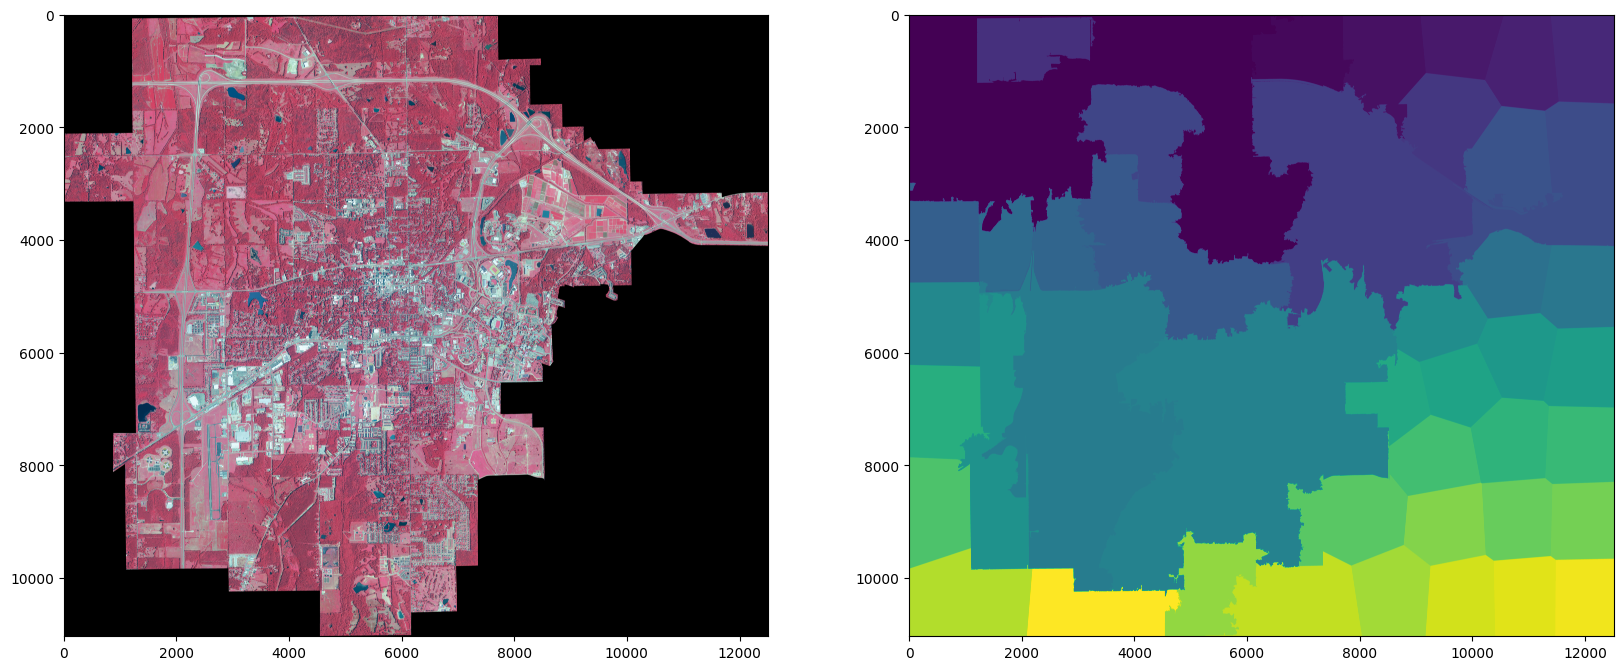

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(okt_imagery)
ax[1].imshow(segmented_image)


In [16]:
@numba.njit(parallel=True)
def process_chunk_vectorized(
    chunk_seg: np.ndarray, 
    lc_probs_chunk: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Update probabilities in a chunk based on segment averages.

    For each unique segment in the chunk, compute the mean probability 
    across all pixels for each channel and assign the computed mean to 
    all pixels in that segment.

    Parameters
    ----------
    chunk_seg : np.ndarray
        2D array representing segmentation labels for the current image chunk.
    lc_probs_chunk : np.ndarray
        3D array with shape (channels, height, width) containing probability values 
        corresponding to the image chunk.

    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        A tuple containing:
        - The segmentation chunk with unchanged labels.
        - The updated probability chunk with each pixel replaced by its channel mean.
    """
    unique_segments = np.unique(chunk_seg)
    
    # Loop over each unique segment in parallel.
    for s in prange(unique_segments.shape[0]):
        segment = unique_segments[s]
        # Boolean mask: True for pixels belonging to the current segment.
        mask = (chunk_seg == segment)
        
        # Process each probability channel.
        for i in range(lc_probs_chunk.shape[0]):
            s_val = 0.0
            cnt = 0
            # Sum and count probability values over all pixels in the segment.
            for idx in range(mask.size):
                if mask.flat[idx]:
                    s_val += lc_probs_chunk[i].flat[idx]
                    cnt += 1
            # Compute mean probability for the segment; avoid division by zero.
            mean_val = s_val / cnt if cnt > 0 else 0.0
            # Assign the mean value back into each pixel of the segment.
            for idx in range(mask.size):
                if mask.flat[idx]:
                    lc_probs_chunk[i].flat[idx] = mean_val
    return chunk_seg, lc_probs_chunk



def process_chunk(
    image_chunk: np.ndarray,
    seg_func: Callable[..., np.ndarray],
    seg_params: Dict[str, Any],
    lc_probs_chunk: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Segment a chunk of the image and update its corresponding probability values.

    Applies a segmentation function to a chunk of the image and then uses the 
    vectorized processing to update the probability chunk based on segment means.

    Parameters
    ----------
    image_chunk : np.ndarray
        A sub-array of the overall image to be segmented.
    seg_func : Callable[..., np.ndarray]
        Segmentation function (e.g., felzenszwalb) that accepts the image chunk and parameters.
    seg_params : dict
        Dictionary of parameters to be passed to the segmentation function.
    lc_probs_chunk : np.ndarray
        A sub-array of the probability array corresponding to the image chunk.

    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        A tuple containing:
        - The segmentation mask for the chunk.
        - The updated probability chunk.
    """
    # Segment the image chunk with the provided segmentation function.
    chunk_seg = seg_func(image_chunk, **seg_params)
    # Update probability values based on segment statistics.
    chunk_seg, lc_probs_chunk = process_chunk_vectorized(chunk_seg, lc_probs_chunk)
    return chunk_seg, lc_probs_chunk


def process_wrapper(
    arg: Tuple[np.ndarray, Callable[..., np.ndarray], Dict[str, Any], np.ndarray, int, int]
) -> Tuple[int, int, np.ndarray, np.ndarray]:
    """
    Unpack arguments and process a single image-chunk.

    Parameters
    ----------
    arg : tuple
        A tuple containing:
        - image_chunk: np.ndarray
        - seg_func: segmentation function
        - seg_params: parameters for seg_func
        - lc_probs_chunk: np.ndarray for current chunk probabilities
        - i, j: starting indices in the full image

    Returns
    -------
    tuple
        A tuple containing:
        - i: row index of chunk start.
        - j: column index of chunk start.
        - chunk_seg: processed segmentation of the chunk.
        - updated_chunk_probs: updated probability chunk.
    """
    img_chunk, seg_func, seg_params, lc_chunk, i, j = arg
    chunk_seg, updated_chunk_probs = process_chunk(img_chunk, seg_func, seg_params, lc_chunk)
    return i, j, chunk_seg, updated_chunk_probs

def parallel_segment(
    image: np.ndarray,
    lc_probs: np.ndarray,
    seg_func: Callable[..., np.ndarray],
    seg_params: Dict[str, Any],
    chunk_size: int = 1024,
    n_procs: int = 16,
    enable_pbar: bool = True,
) -> Tuple[np.ndarray, np.ndarray, Dict]:
    """
    Segment a full image in parallel and update probability values accordingly.

    Divides the image and its corresponding probability array into chunks, processes each 
    chunk in parallel, and then reassembles the full segmented image, updated probabilities, 
    and a mapping from segment IDs to normalized mean probabilities.

    Parameters
    ----------
    image : np.ndarray
        The full image data as a numpy array with shape (height, width, channels) or similar.
    lc_probs : np.ndarray
        The probability array with shape (channels, height, width).
    seg_func : Callable[..., np.ndarray]
        The segmentation function to apply to each image chunk.
    seg_params : dict
        Parameters for the segmentation function.
    chunk_size : int, optional
        The size of each chunk (default is 1024). The image is divided into non-overlapping 
        chunks of shape (chunk_size, chunk_size).
    n_procs : int, optional
        Number of processes to run in parallel (default is 16).

    Returns
    -------
    Tuple[np.ndarray, np.ndarray, dict]
        A tuple containing:
        - segmented_image: np.ndarray with unique segment labels for the whole image.
        - processed_probs: np.ndarray with updated probability values.
        - segment_mapping: Dictionary mapping each segment ID to its normalized mean probabilities.
    """
    img_height, img_width = image.shape[:2]
    segmented_image = np.zeros((img_height, img_width), dtype=np.int32)
    processed_probs = np.zeros(lc_probs.shape, dtype=lc_probs.dtype)
    segment_mapping: Dict = {}

    # Generate a list of chunk starting indices.
    chunks = [(i, j) for i in range(0, img_height, chunk_size) for j in range(0, img_width, chunk_size)]
    
    # Create shared memory for the lc_probs array to avoid duplicating large arrays.
    shm_probs = SharedMemory(create=True, size=lc_probs.nbytes)
    shared_probs = np.ndarray(lc_probs.shape, dtype=lc_probs.dtype, buffer=shm_probs.buf)
    shared_probs[:] = lc_probs[:]

    # Prepare arguments for processing each chunk.
    args = []
    for i, j in chunks:
        img_chunk = image[i:i+chunk_size, j:j+chunk_size]
        # Copy the corresponding chunk of probability data.
        lc_chunk = shared_probs[:, i:i+chunk_size, j:j+chunk_size].copy()
        args.append((img_chunk, seg_func, seg_params, lc_chunk, i, j))



    running_max = 0
    # Process chunks in parallel using a process pool.
    with mp.Pool(n_procs) as pool:
        for i, j, chunk_seg, updated_chunk_probs in tqdm(
            pool.imap_unordered(process_wrapper, args),
            total=len(args),
            desc="Processing chunks",
            unit="chunk",
            disable=not enable_pbar,
        ):
            # Ensure unique segment labels across chunks.
            chunk_seg += running_max
            segmented_image[i:i+chunk_size, j:j+chunk_size] = chunk_seg
            processed_probs[:, i:i+chunk_size, j:j+chunk_size] = updated_chunk_probs
            # For each segment, compute normalized mean probabilities.
            unique_ids = np.unique(chunk_seg)
            for seg in unique_ids:
                mask = (chunk_seg == seg)
                mean_probs = np.mean(updated_chunk_probs[:, mask], axis=1)
                total = np.sum(mean_probs)
                segment_mapping[seg] = mean_probs / total if total != 0 else mean_probs
            running_max = np.max(unique_ids) + 1

    # Clean up shared memory.
    shm_probs.close()
    shm_probs.unlink()

    return segmented_image, processed_probs, segment_mapping



def postprocess_image(okt_imagery, lc_probs, felzenszwalb, best_params, chunk_size=1024, n_procs=16, enable_pbar=True):
    _, processed_probs, _ = parallel_segment(
        okt_imagery, lc_probs, felzenszwalb, best_params, chunk_size=chunk_size, n_procs=n_procs
    )
    return processed_probs

def main():
    best_params = {'scale': 426.63398327663225, 'min_size': 5, 'sigma': 0.01731103186335133, 'unsharp_radius': 9, 'unsharp_amount': 8.026268634276002}
    processed_probs = postprocess_image(okt_imagery, lc_probs, felzenszwalb, best_params, chunk_size=256, n_procs=mp.cpu_count())

if __name__ == '__main__':
    main()

Processing chunks:   0%|          | 0/2156 [00:00<?, ?chunk/s]


NameError: name 'process_chunk' is not defined

In [21]:
import os
gdf = gpd.read_file('./data/shapefiles/okt_ms_low_confidence_point_samples.gpkg', layer='okt_ms_low_confidence_point_samples')
# save as only layer in geopackage
os.remove('./data/shapefiles/okt_ms_low_confidence_point_samples.gpkg')
gdf.to_file('./data/shapefiles/okt_ms_low_confidence_point_samples.gpkg')

In [23]:
gdf = gpd.read_file('./data/shapefiles/okt_ms_low_confidence_point_samples.gpkg')
gdf

,confidence,pred_class_index,pred_class_name,true_class_index,true_class_name,pred_probs,geometry
0,22,6,Low Vegetation/Herbaceous,3,Impervious (paved surfaces),[0.08 0.07 0.22 0.21 0.05 0.22 0.04 0.07],POINT (592432.439 1408439.185)
1,23,6,Low Vegetation/Herbaceous,5,Tree Canopy/Woody Vegetation,[0.11 0.04 0.06 0.15 0.21 0.23 0.06 0.1 ],POINT (583757.439 1408682.185)
2,22,3,Impervious (paved surfaces),2,Impervious (raised structures),[0.06 0.2 0.22 0.1 0.07 0.18 0.06 0.06],POINT (589495.439 1406570.185)
3,22,2,Impervious (raised structures),2,Impervious (raised structures),[0.07 0.22 0.13 0.17 0.08 0.14 0.06 0.09],POINT (582477.439 1403383.185)
4,18,6,Low Vegetation/Herbaceous,3,Impervious (paved surfaces),[0.08 0.17 0.17 0.14 0.06 0.18 0.05 0.1 ],POINT (587707.439 1405652.185)
...,...,...,...,...,...,...,...
195,22,5,Tree Canopy/Woody Vegetation,6,Low Vegetation/Herbaceous,[0.12 0.06 0.08 0.12 0.22 0.21 0.04 0.09],POINT (585347.439 1407454.185)
196,21,8,Unclassified,8,Unclassified,[0.11 0.08 0.12 0.14 0.08 0.18 0.05 0.21],POINT (586606.439 1407085.185)
197,20,5,Tree Canopy/Woody Vegetation,5,Tree Canopy/Woody Vegetation,[0.1 0.11 0.06 0.12 0.2 0.18 0.07 0.11],POINT (587507.439 1404295.185)
198,21,8,Unclassified,8,Unclassified,[0.11 0.06 0.04 0.09 0.19 0.19 0.07 0.21],POINT (585852.439 1409720.185)


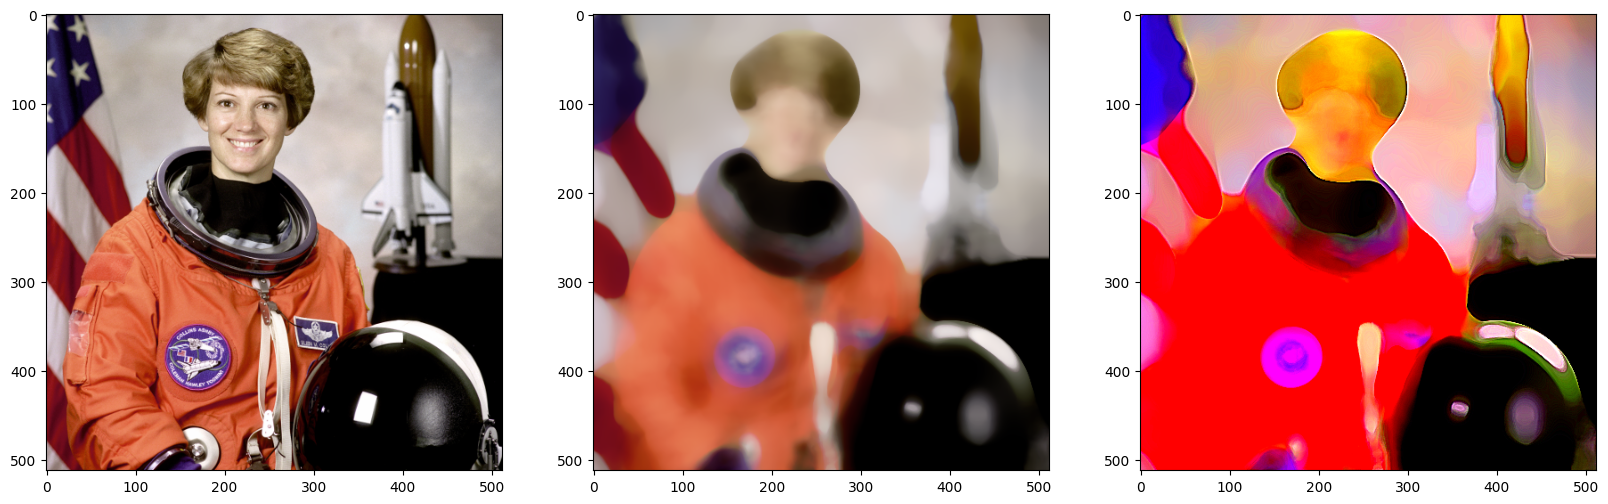

In [ ]:
from skimage.filters.rank import median
from skimage.filters import unsharp_mask
from skimage.morphology import disk
from skimage.data import astronaut
from skimage.segmentation import felzenszwalb, find_boundaries
from skimage.util import draw
import matplotlib.pyplot as plt

img = astronaut()

fig, ax = plt.subplots(1, 4, figsize=(20, 10))
ax[0].imshow(img)

for i in range(3):
    img[:, :, i] = median(img[:, :, i], disk(20))
ax[1].imshow(img)

img = unsharp_mask(img, radius=1, amount=10)
ax[2].imshow(img)


plt.show()

In [110]:
from glob import glob
from src.mslandcover.models import UNet
from src.mslandcover.utils import load_pth
import numpy as np
import rasterio as rio
import torch
# lets take another approach:
# using the val and test splits, take our model and derive lc probs
# for each image, then optimize the segmentation algorithm to minimize
# cross entropy on those images

# first, lets get the val and test splits
# X_paths = glob('./data/splits/val/input/*.tif') + glob('./data/splits/test/input/*.tif')
y_paths = glob('./data/splits/val/target/*.tif') #  + glob('./data/splits/test/target/*.tif')
X_paths = [path.replace('target', 'input') for path in y_paths]

# now, load the model
X = np.stack([rio.open(path).read().transpose(1, 2, 0) / 255.0 for path in X_paths])
y = np.stack([rio.open(path).read().squeeze() for path in y_paths])

mean = load_pth('./weights/pretrain_mean.pth').numpy()
std = load_pth('./weights/pretrain_std.pth').numpy()

X_norm = (X - mean) / std
X_torch = torch.from_numpy(X_norm).permute(0, 3, 1, 2).float()

model = UNet(num_classes=8)
model.load_state_dict(load_pth('./weights/finetuned_unet2/best_model.pth', map_location='cpu'))

<All keys matched successfully>

In [112]:
device = torch.device('mps')
model = model.to(device)

lc_probs = []
batch_size = 32
for i in range(0, X_torch.shape[0], batch_size):
    with torch.no_grad():
        X_batch = X_torch[i:i+batch_size].to(device)
        y_pred = model(X_batch)
        lc_probs.append(y_pred)
lc_probs = torch.cat(lc_probs, dim=0).cpu().numpy()

KeyboardInterrupt: 

In [29]:
lc_probs.shape

(61, 8, 256, 256)

In [31]:
from typing import Union, Dict
from skimage.segmentation import felzenszwalb
from skimage.filters import unsharp_mask, median
from skimage.morphology import disk
from numba import njit, prange


# convert y from (n, h, w) to (n, c, h, w) where c is the number of classes
y_one_hot = np.stack([np.eye(8)[y_i - 1] for y_i in y]).transpose(0, 3, 1, 2)
# cross_entropy(y_one_hot, lc_probs)

def cross_entropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred))

lc_classes = np.argmax(lc_probs, axis=1)
init_ce = cross_entropy(y_one_hot, lc_probs)




In [23]:
import multiprocess as mp
import optuna

print(X.shape)
segment_params = {
    'median_radius': 3,
    'unsharp_radius': 1,
    'unsharp_amount': 10,
    'seg_scale': 20,
    'seg_min_size': 10,
}
processed_probs = segment_and_process(X[0], lc_probs[0], seg_params=segment_params)
print(processed_probs.shape)

(131, 256, 256, 3)
(8, 256, 256)


In [35]:
import multiprocess as mp
# with mp.Pool(mp.cpu_count()) as pool:
    # results = pool.starmap(segment_and_process, [(img, probs, segment_params) for img, probs in zip(X, lc_probs)])

# y_processed = np.stack(results)
# y_processed.shape

trial_ce = cross_entropy(y_one_hot, lc_probs)
print(f'Initial CE: {init_ce:.4f}')
print(f'Trial CE: {trial_ce:.4f}')

Initial CE: 2618401.0681
Trial CE: 2618401.0681


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import optuna
from tqdm import tqdm
import multiprocess as mp

def objective(trial: optuna.Trial) -> float:
    
    segment_params = {
        'median_radius': trial.suggest_int('median_radius', 0, 10),
        'unsharp_radius': trial.suggest_int('unsharp_radius', 0, 20),
        'unsharp_amount': trial.suggest_float('unsharp_amount', 0.0, 10.0),
        'seg_scale': trial.suggest_float('seg_scale', 10, 500),
        'seg_min_size': trial.suggest_int('seg_min_size', 5, 100),
    }
    
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.starmap(segment_and_process, [(img, probs, segment_params) for img, probs in zip(X, lc_probs)])
    
    y_processed = np.stack(results)
    
    y_processed_labels = np.argmax(y_processed, axis=1).flatten()
    y_flat = y.flatten()
    acc = accuracy_score(y_flat, y_processed_labels)
    trial.set_user_attr('accuracy', acc)
    
    for average_type in ['micro', 'macro', 'weighted']:
        precision = precision_score(y_flat, y_processed_labels, average=average_type, zero_division=0)
        recall = recall_score(y_flat, y_processed_labels, average=average_type, zero_division=0)
        f1 = f1_score(y_flat, y_processed_labels, average=average_type, zero_division=0)
        
        trial.set_user_attr(f'{average_type}_precision', precision)
        trial.set_user_attr(f'{average_type}_recall', recall)
        trial.set_user_attr(f'{average_type}_f1_score', f1)
    
    return cross_entropy(y_one_hot, y_processed)

sampler = optuna.samplers.TPESampler(seed=1701)
study = optuna.create_study(sampler=sampler, study_name='seg_optimization', direction='minimize')
study.optimize(objective, n_trials=256, n_jobs=1)

[I 2025-02-09 01:55:30,684] A new study created in memory with name: seg_optimization
[I 2025-02-09 01:55:38,925] Trial 0 finished with value: 2701324.251401837 and parameters: {'median_radius': 0, 'unsharp_radius': 2, 'unsharp_amount': 5.187439362099039, 'seg_scale': 245.50320978968819, 'seg_min_size': 89}. Best is trial 0 with value: 2701324.251401837.
[I 2025-02-09 01:55:50,712] Trial 1 finished with value: 3107016.864206183 and parameters: {'median_radius': 9, 'unsharp_radius': 4, 'unsharp_amount': 0.8857525583590986, 'seg_scale': 487.0742650970825, 'seg_min_size': 70}. Best is trial 0 with value: 2701324.251401837.
[I 2025-02-09 01:55:59,377] Trial 2 finished with value: 2639684.945502353 and parameters: {'median_radius': 3, 'unsharp_radius': 3, 'unsharp_amount': 3.2926726010018106, 'seg_scale': 195.38452364927298, 'seg_min_size': 94}. Best is trial 2 with value: 2639684.945502353.
[I 2025-02-09 01:56:07,553] Trial 3 finished with value: 2694437.8574316464 and parameters: {'median

KeyboardInterrupt: 

In [37]:
print(study.best_params)
print(study.best_value)

improvement = (init_ce - study.best_value) / init_ce
print(f'Improvement: {improvement:.2%}')

{'median_radius': 4, 'unsharp_radius': 1, 'unsharp_amount': 2.720967536019157, 'seg_scale': 145.15664037618663, 'seg_min_size': 5}
2477979.0267670774
Improvement: 5.36%


In [126]:
# use test sets
y_paths = glob('./data/splits/test/target/*.tif') #  + glob('./data/splits/test/target/*.tif')
X_paths = [path.replace('target', 'input') for path in y_paths]

# now, load the model
X = np.stack([rio.open(path).read().transpose(1, 2, 0) / 255.0 for path in X_paths])
y = np.stack([rio.open(path).read().squeeze() for path in y_paths])


In [116]:
X_torch.mean()



tensor(0.0564)

In [128]:
print(y.shape)
y_one_hot = np.stack([np.eye(8)[y_i - 1] for y_i in y]).transpose(0, 3, 1, 2)
print(y_one_hot.shape)

(70, 256, 256)
(70, 8, 256, 256)


In [117]:

y_one_hot = np.stack([np.eye(8)[y_i - 1] for y_i in y]).transpose(0, 3, 1, 2)

mean = load_pth('./weights/pretrain_mean.pth').numpy()
std = load_pth('./weights/pretrain_std.pth').numpy()

X_norm = (X - mean) / std
X_torch = torch.from_numpy(X_norm).permute(0, 3, 1, 2).float()

lc_probs = []
batch_size = 32
for i in range(0, X_torch.shape[0], batch_size):
    with torch.no_grad():
        X_batch = X_torch[i:i+batch_size].to(device)
        y_pred = model(X_batch)
        lc_probs.append(y_pred)
lc_probs = torch.cat(lc_probs, dim=0).cpu().numpy()

init_test_ce = cross_entropy(y_one_hot, lc_probs)
with mp.Pool(mp.cpu_count()) as pool:
    results = pool.starmap(segment_and_process, [(img, probs, study.best_params) for img, probs in zip(X, lc_probs)])
new_ce = cross_entropy(y_one_hot, np.stack(results))

print(f'Initial Test CE: {init_test_ce:.4f}')
print(f'Optimized Test CE: {new_ce:.4f}')
improvement = (init_test_ce - new_ce) / init_test_ce
print(f'Improvement: {improvement:.2%}')

Initial Test CE: 3494208.5642
Optimized Test CE: 3206820.5142
Improvement: 8.22%


In [118]:
init_test_f1 = f1_score(y.flatten(), np.argmax(lc_probs, axis=1).flatten() + 1, average='macro')
new_f1 = f1_score(y.flatten(), np.argmax(np.stack(results), axis=1).flatten() + 1, average='macro')
improvement = (new_f1 - init_test_f1) / init_test_f1

print(f'Initial Test F1: {init_test_f1:.4f}')
print(f'Optimized Test F1: {new_f1:.4f}')
print(f'F1 Improvement: {improvement:.2%}')

Initial Test F1: 0.5704
Optimized Test F1: 0.5911
F1 Improvement: 3.63%


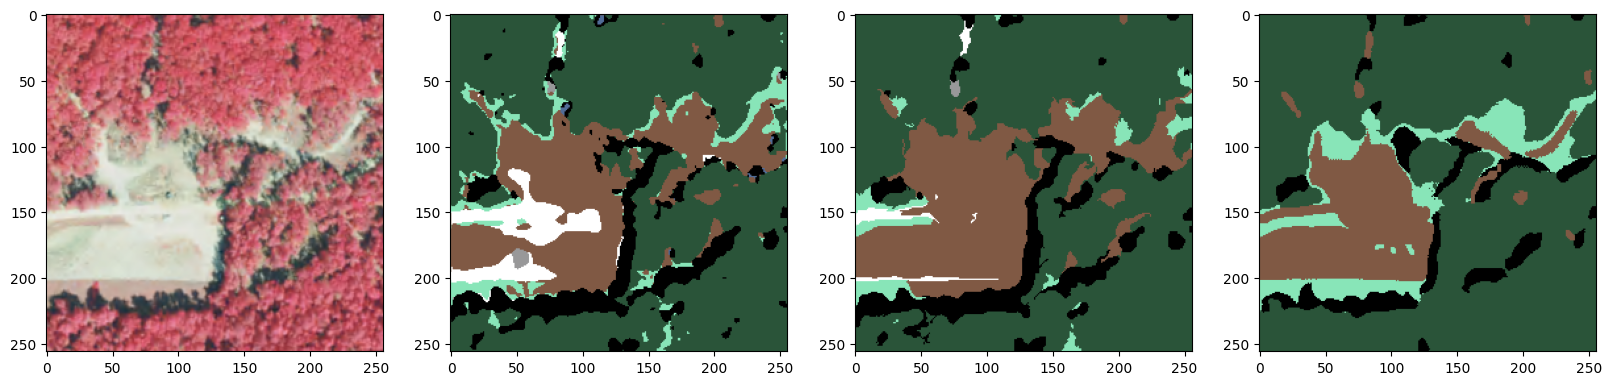

In [83]:
import matplotlib.pyplot as plt
from src.mslandcover.config import LEGEND_COLORS_RGB

def create_color_lcmap(y_pred):
    
    y_pred_rgb = np.zeros((y_pred.shape[0], y_pred.shape[1], 3), dtype=np.uint8)
    
    for i in range(8):
        y_pred_rgb[y_pred == i] = LEGEND_COLORS_RGB[i]
    
    return y_pred_rgb

fig, ax = plt.subplots(1, 4, figsize=(20, 10))

idx = 40
ax[0].imshow(X[idx])

ax[1].imshow(create_color_lcmap(np.argmax(lc_probs[idx], axis=0) + 1))
ax[2].imshow(create_color_lcmap(np.argmax(results[idx], axis=0) + 1))

ax[3].imshow(create_color_lcmap(y[idx]))

plt.show()

In [123]:
from src.mslandcover.data.datasets import FineTuneDataset
from torch.utils.data import DataLoader

test_dataset = FineTuneDataset(
    data_paths=X_paths,
    target_paths=y_paths,
    mean=mean,
    std=std,
    transform=None,
)

test_loader = DataLoader(test_dataset, batch_size=3, shuffle=False)

device = 'mps'
model.eval()
y_preds = []
y_trues = []
torch.set_grad_enabled(False)
for i, (X, y) in enumerate(test_loader):
    X, y = X.to(device), y.to(device)
    y_preds.append(model(X))
    y_trues.append(y)



Preloading targets: 100%|██████████| 70/70 [00:00<00:00, 343.94images/s]


In [ ]:
# compare data loading scenarios

from src.mslandcover.data.datasets import FineTuneDataset
from src.mslandcover.models import UNet
from src.mslandcover.utils import load_pth, get_torch_device
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score

device = get_torch_device()
model = UNet()
model.load_state_dict(load_pth('./weights/finetuned_unet2/best_model.pth', map_location='cpu'))
model = model.to(device)
model.eval()
torch.set_grad_enabled(False)

mean = load_pth('./weights/pretrain_mean.pth')
std = load_pth('./weights/pretrain_std.pth')

X_paths = glob('./data/splits/test/input/*.tif')
y_paths = glob('./data/splits/test/target/*.tif')
test_dataset = FineTuneDataset(
    data_paths=X_paths,
    target_paths=y_paths,
    mean=mean,
    std=std,
    transform=None,
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

X_test = []
y_test = []
y_hat_test = []

for X, y in test_loader:
    X_test.append(X.numpy())
    y_test.append(y.numpy())
    y_hat_test.append(model(X.to(device)).cpu().numpy())


X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)
y_hat_test = np.concatenate(y_hat_test, axis=0)

f1_1 = f1_score(y_test.flatten(), np.argmax(y_hat_test, axis=1).flatten(), average='macro')
print(f'F1 Score: {f1_1:.4f}')

Preloading targets: 100%|██████████| 70/70 [00:00<00:00, 324.99images/s]


F1 Score: 0.7377


In [174]:
X_paths = [path.replace('target', 'input') for path in y_paths]

X_test_2 = np.array([rio.open(path).read().transpose(1, 2, 0) / 255.0 for path in X_paths])
y_test_2 = np.array([rio.open(path).read().squeeze() for path in y_paths])

X_test_2 = (X_test_2 - mean.numpy()) / std.numpy()


print(X_test_2.shape)


batch_size = 8
print(device)

model = model.eval()
torch.set_grad_enabled(False)

y_hat_test_2 = []
for i in range(0, X_test_2.shape[0], batch_size):
    print(i)
    X_batch = torch.from_numpy(X_test_2[i:i+batch_size]).permute(0, 3, 1, 2).float().to(device)
    y_hat_batch = model(X_batch)
    print(len(y_hat_batch))
    y_hat_test_2.append(y_hat_batch.cpu().numpy())

(70, 256, 256, 3)
mps
0
8
8
8
16
8
24
8
32
8
40
8
48
8
56
8
64
6


In [176]:
y_hat_test_2_cat = np.concatenate(y_hat_test_2, axis=0)
print(y_hat_test_2_cat.shape)
print(y_test_2)

f1_2 = f1_score(y_test_2.flatten() - 1, np.argmax(y_hat_test_2_cat, axis=1).flatten(), average='macro')
print(f'F1 Score: {f1_2:.4f}')

(70, 8, 256, 256)
[[[6 6 6 ... 6 6 6]
  [6 6 6 ... 6 6 6]
  [6 6 6 ... 6 6 6]
  ...
  [5 5 5 ... 5 5 5]
  [5 5 5 ... 5 5 5]
  [5 5 5 ... 5 5 5]]

 [[5 5 5 ... 6 6 6]
  [5 5 5 ... 6 6 6]
  [5 5 5 ... 6 6 6]
  ...
  [5 5 5 ... 6 6 6]
  [5 5 5 ... 6 6 6]
  [5 5 5 ... 6 6 6]]

 [[6 6 6 ... 5 5 5]
  [6 6 6 ... 5 5 5]
  [6 6 6 ... 5 5 5]
  ...
  [4 4 4 ... 5 5 5]
  [4 4 4 ... 5 5 5]
  [4 4 4 ... 5 5 5]]

 ...

 [[6 5 5 ... 6 6 6]
  [5 5 5 ... 6 6 6]
  [5 5 5 ... 6 6 6]
  ...
  [5 5 5 ... 5 5 5]
  [5 5 5 ... 5 5 5]
  [5 5 5 ... 5 5 5]]

 [[6 6 6 ... 5 5 5]
  [6 6 6 ... 5 5 5]
  [6 6 6 ... 5 5 5]
  ...
  [6 6 6 ... 5 5 5]
  [6 6 6 ... 5 5 5]
  [6 6 6 ... 5 5 5]]

 [[5 5 5 ... 6 6 6]
  [5 5 5 ... 6 6 6]
  [5 5 5 ... 6 6 6]
  ...
  [3 3 3 ... 5 5 5]
  [3 3 3 ... 5 5 5]
  [3 3 3 ... 5 5 5]]]
F1 Score: 0.7377
